# ✈️ ETL de Tráfico Aéreo con OpenSky Network  
## Ingesta, Normalización, Enriquecimiento y Preparación para Orquestación y Nube

La disponibilidad de datos aeronáuticos en tiempo real permite analizar patrones de movilidad aérea,  
el comportamiento dinámico de aeronaves y variaciones operativas a escala global.  
Este proyecto desarrolla un pipeline **ETL completo**, basado en la arquitectura  
**Bronze → Silver → Gold**, utilizando datos del endpoint público de **OpenSky Network**.

El objetivo central es construir un flujo profesional de ingeniería de datos que permita:

- **ingestar datos estáticos y dinámicos**,  
- **limpiarlos, normalizarlos y enriquecerlos**,  
- **almacenarlos eficientemente en Delta Lake**,  
- **generar un dataset final listo para análisis**,  
- y dejar preparado el proyecto para su **orquestación con Prefect** y  
  posterior **migración a Azure Cloud**.

---

## 🛩️ Variables clave provistas por OpenSky

- identificador único **ICAO24**  
- país de origen de la aeronave  
- latitud y longitud  
- altitudes barométricas y geométricas  
- velocidad, rumbo y tasa vertical  
- estado en tierra o en vuelo  
- timestamp del servidor  
- metadatos estáticos (fabricante, modelo, typecode, año, motores)

El proyecto integra datos **dinámicos** y **estáticos** para construir un dataset final consolidado en *Gold*.

---

# 🎯 Objetivos del pipeline

## **Bronze — Extracción**
- Consumir el endpoint `states/all` y el archivo estático de metadatos.  
- Convertir las estructuras JSON en tablas tabulares.  
- Incorporar timestamps y columnas temporales.  
- Almacenar el material crudo en **Delta Lake**.

## **Silver — Transformación**
- Normalizar columnas, eliminar nulos estructurales y tipificar correctamente.  
- Estandarizar fechas, coordenadas, categorías y valores booleanos.  
- Crear columnas temporales derivadas (`snapshot_time`, `snapshot_hour`).  
- Dejar tablas limpias y consistentes, listas para enriquecimiento.

## **Gold — Métricas, Enriquecimiento y Visualizaciones**
- Integrar el snapshot dinámico con metadatos del avión vía `icao24`.  
- Calcular métricas aeronáuticas clave (velocidad, altitudes, países).  
- Generar visualizaciones básicas del tráfico aéreo.  
- Exportar opcionalmente a CSV/Parquet.  
- Construir el **dataset final analítico**.

---

# 🧭 Alcance actual y roadmap

Este notebook implementa la totalidad del pipeline **local**, y deja el proyecto preparado para:

### 🔹 **Orquestación con Prefect (próximo paso inmediato)**
- flujos automáticos  
- ejecuciones programadas  
- logging y monitoreo centralizado  
- tareas desacopladas por capa  

### 🔹 **Migración progresiva a Azure Cloud**
- almacenamiento en **Azure Data Lake / Blob Storage**  
- procesamiento distribuido con **Azure Databricks**  
- orquestación con **Azure Data Factory** o Prefect Cloud  
- despliegue de un Data Lake escalable  

---

## 🔁 Reproducibilidad

- Dependencias → `requirements.txt`  
- Configuración → `pipeline.conf`  
- Funciones auxiliares → `src/etl_utils.py`  
- Data Lake local → `data/etl_datalake/`  

---

## 📘 Estructura del notebook

0) Configuración inicial  
1) Capa Bronze — Ingesta y almacenamiento crudo  
2) Capa Silver — Limpieza, normalización y particionado  
3) Capa Gold — Métricas, enriquecimiento y visualizaciones  
4) Exportaciones opcionales  
5) Conclusiones y roadmap futuro
---


## 0. Configuración inicial

En este paso se importan todas las librerías necesarias y las funciones auxiliares definidas en `etl_utils.py`.  
Este enfoque permite mantener el notebook **ordenado, modular y fácilmente reproducible**, centralizando en un único módulo las operaciones comunes del pipeline ETL: extracción desde la API pública de **OpenSky Network**, normalización del JSON, estandarización de columnas y escritura en las distintas capas del **Data Lake local** (Bronze → Silver → Gold).

El objetivo de esta sección es garantizar que todas las dependencias estén correctamente cargadas antes de iniciar el proceso de extracción y almacenamiento.

In [1]:
import sys
import os

# Se agrega la carpeta src al path (sube un nivel desde /notebooks)
sys.path.append(os.path.abspath("../src"))

# Funciones auxiliares
from etl_utils import *

# Librerías comunes
import pandas as pd
from pprint import pprint

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


## 1. Autenticación y lectura de configuración

La configuración del proyecto se administra mediante el archivo `pipeline.conf`,  
que centraliza parámetros como:
- la **URL base** de la API de OpenSky Network  
- credenciales opcionales para *Basic Auth* (en caso de usarse)  
- rutas del **Data Lake local**

Aunque la API pública de OpenSky no requiere autenticación obligatoria,almacenar parámetros en un archivo de configuración permite:
- mantener el notebook limpio  
- evitar credenciales expuestas en el código  
- facilitar la migración futura a servicios en la nube (Azure Key Vault)

El archivo se lee mediante `ConfigParser`, lo que permite obtener los valores  
en forma segura y reusable.


In [2]:
# Se instancia el parser y se lee el archivo de configuración
from configparser import ConfigParser

parser = ConfigParser()
parser.read("../pipeline.conf")

['../pipeline.conf']

In [3]:
# Parámetros de conexión
api_config = parser["api-opensky"]
base_url = api_config["base_url"]

In [4]:
print("📄 Configuración cargada correctamente.")
print(f"URL base: {base_url}")

📄 Configuración cargada correctamente.
URL base: https://opensky-network.org/api/states/all


In [5]:
# Prueba de conexión a la API OpenSky
response = requests.get(base_url)

if response.status_code == 200:
    data = response.json()
    print(f"La petición fue exitosa. Tipo de respuesta: {type(data)}")

    # Claves principales del JSON
    print(f"Claves principales recibidas: {list(data.keys())[:5]}")

    # Inspección parcial de 'states'
    print("\nPrimeras 2 aeronaves registradas:")
    pprint(data["states"][:2])

else:
    print(f"❌ Error en la petición: {response.status_code}, {response.content}")
print("✅ Prueba de conexión a la API realizada.")

La petición fue exitosa. Tipo de respuesta: <class 'dict'>
Claves principales recibidas: ['time', 'states']

Primeras 2 aeronaves registradas:
[['80162c',
  'AXB2959 ',
  'India',
  1764504051,
  1764504051,
  89.1424,
  24.7532,
  9753.6,
  False,
  216.46,
  237.03,
  0,
  None,
  10294.62,
  '2610',
  False,
  0],
 ['4b1819',
  'SWR8XA  ',
  'Switzerland',
  1764504050,
  1764504050,
  8.568,
  47.4557,
  None,
  True,
  1.29,
  95.62,
  None,
  None,
  None,
  '3063',
  False,
  0]]
✅ Prueba de conexión a la API realizada.


## 2. Capa Bronze — Extracción y almacenamiento de datos crudos

En esta etapa se realiza la **extracción directa de datos** desde la API pública de **OpenSky Network**, que provee información en tiempo real sobre aeronaves detectadas a nivel global.  
El objetivo es obtener el conjunto completo de registros tal como es devuelto por el endpoint `states/all` y conservarlo en su forma más fiel dentro de la capa **🟤 Bronze** del Data Lake.

Los datos obtenidos incluyen:

- Identificador único **ICAO24**  
- Indicativo de llamada (**callsign**)  
- País de origen  
- Posición geográfica (latitud, longitud)  
- Altitudes barométrica y geométrica  
- Velocidad, rumbo y tasa vertical  
- Estado operativo (en tierra o en vuelo)  
- Timestamp del servidor (`time`) correspondiente a la captura

Cada aeronave es representada inicialmente como una lista ordenada de 17 elementos, por lo que en esta etapa se prioriza **preservar los datos crudos** antes de aplicar procesos de estructuración o limpieza.

Los datos se almacenan en **formato Delta Lake**, dentro del directorio:

`data/etl_datalake/bronze/api_opensky/`

empleando el modo **`overwrite`**, ya que la información corresponde a un snapshot puntual del estado global del tráfico aéreo y puede reemplazarse completamente en cada actualización.


### 2.1 Extracción de datos estáticos

Se realiza una *ingesta full* sobre el recurso estático `aircraftDatabase.csv` provisto por **OpenSky Network**, que contiene información descriptiva sobre aeronaves (modelo, fabricante, typecode, operador, entre otros metadatos relevantes).

Si bien este dataset no proviene de un endpoint API, constituye la **fuente oficial de referencia** publicada por la plataforma.  
Dado que cambia muy poco en el tiempo, se incorpora en su totalidad en cada ejecución y se sobrescribe la versión previa (*mode="overwrite"*).

Este enfoque evita duplicados, simplifica el pipeline y garantiza la disponibilidad de la versión más reciente.

Los datos se almacenan en la capa 🟤 **Bronze** en formato **Delta Lake**, preservados tal como fueron obtenidos.

In [6]:
# --- Extracción de datos estáticos — OpenSky aircraft metadata ---

# URL del recurso estático oficial
metadata_url = "https://opensky-network.org/datasets/metadata/aircraftDatabase.csv"

# Descarga del archivo CSV
# Nota: Estos metadatos cambian muy poco, por lo que se aplicará ingesta "full"
df_aircraft = pd.read_csv(metadata_url)

# Vista preliminar del dataset cargado
print("📄 Dataset de metadatos cargado correctamente.")
print(f"Filas: {df_aircraft.shape[0]} | Columnas:, {df_aircraft.shape[1]}")
df_aircraft.head(3)

📄 Dataset de metadatos cargado correctamente.
Filas: 520000 | Columnas:, 27


,icao24,registration,manufacturericao,manufacturername,model,typecode,serialnumber,linenumber,icaoaircrafttype,operator,...,status,built,firstflightdate,seatconfiguration,engines,modes,adsb,acars,notes,categoryDescription
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,False,False,NaN,NaN
1,aa3487,N757F,RAYTHEON,Raytheon Aircraft Company,A36,BE36,E-3121,NaN,L1P,NaN,...,NaN,NaN,NaN,NaN,NaN,False,False,False,NaN,NaN
2,a4fa61,N42MH,PIPER,Piper,PA-31-350,PA31,31-7852015,NaN,L2P,NaN,...,NaN,1977-01-01,NaN,NaN,LYCOMING TI0-540 SER,False,False,False,NaN,NaN


### 2.2 Extracción de datos dinámicos

Para los datos dinámicos se utiliza la información proveniente del endpoint `states/all`, que ofrece el estado en tiempo real de miles de aeronaves a nivel global.  
Dado que estos datos se actualizan continuamente, cada ejecución captura un *snapshot* independiente del tráfico aéreo del momento.

En este caso no se aplica una actualización incremental, ya que el conjunto de aeronaves presentes varía en cada consulta y no existe un identificador temporal que permita rastrear cambios de manera estricta.  
Por ello, cada snapshot se almacena íntegramente en la capa 🟤 *Bronze*, preservando la evolución temporal entre ejecuciones y habilitando análisis posteriores en Silver y Gold.

In [7]:
# --- Extracción de datos dinámicos — OpenSky states/all ---

# Obtención del snapshot dinámico mediante la función auxiliar
json_data = get_opensky_states()

# Vista preliminar del JSON recibido
print("🔑 Claves principales:", list(json_data.keys()))
print("🛫 Cantidad de aeronaves detectadas:", len(json_data["states"]))

# Visualización de los primeros registros crudos
print("\nPrimeras 2 aeronaves (formato crudo):")
pprint(json_data["states"][:2])

🔑 Claves principales: ['time', 'states']
🛫 Cantidad de aeronaves detectadas: 6700

Primeras 2 aeronaves (formato crudo):
[['80162c',
  'AXB2959 ',
  'India',
  1764504097,
  1764504097,
  89.0604,
  24.7045,
  9753.6,
  False,
  216.74,
  236.91,
  0,
  None,
  10294.62,
  '2610',
  False,
  0],
 ['4b1819',
  'SWR8XA  ',
  'Switzerland',
  1764504097,
  1764504097,
  8.5688,
  47.4557,
  None,
  True,
  2.06,
  95.62,
  None,
  None,
  None,
  '3063',
  False,
  0]]


### 2.3 Guardado en Bronze — Delta Lake

Una vez realizada la extracción de los datos estáticos y dinámicos, ambos recursos se almacenan en la capa 🟤 *Bronze* del Data Lake en formato **Delta Lake**.  
En esta etapa no se aplican transformaciones ni procesos de limpieza: los datos se preservan tal como fueron obtenidos desde la API, cumpliendo el propósito de Bronze como zona de almacenamiento crudo.

Los metadatos estáticos se guardan mediante una *ingesta full* (mode="overwrite"), ya que su contenido cambia muy poco y resulta más simple reemplazar el dataset completo en cada ejecución.

Los datos dinámicos provenientes de `states/all` se guardan como snapshots independientes, manteniendo la trazabilidad temporal de cada captura.  
Este enfoque permite conservar el historial de estados del tráfico aéreo para posteriores análisis en las capas Silver y Gold.

Las rutas de salida se definen dentro del directorio:

`data/etl_datalake/bronze/`

Se utilizan subdirectorios separados para **datos estáticos** y **datos dinámicos**.

In [8]:
# --- Definición de rutas del Data Lake (Bronze) ---
# Para la versión manual del ETL se utiliza un espacio de trabajo independiente,
# evitando interferencias con la versión orquestada del pipeline.

datalake_root = "../data/etl_datalake_manual"

# Carpeta raíz del dominio OpenSky dentro de Bronze
bronze_dir = f"{datalake_root}/bronze/api_opensky"

# Subcarpetas específicas según el tipo de recurso
static_dir  = f"{bronze_dir}/aircraft_metadata"
dynamic_dir = f"{bronze_dir}/states"

print("📁 Rutas definidas (versión manual):")
print("Static  →", static_dir)
print("Dynamic →", dynamic_dir)

📁 Rutas definidas (versión manual):
Static  → ../data/etl_datalake_manual/bronze/api_opensky/aircraft_metadata
Dynamic → ../data/etl_datalake_manual/bronze/api_opensky/states


In [9]:
# --- Guardado en Bronze — Metadatos estáticos (Delta Lake) ---

# Ingesta completa: se sobrescribe en cada ejecución al tratarse de datos muy estables.
save_data_as_delta(
    df=df_aircraft,
    path=static_dir,
    mode="overwrite"
)

print("🟤 Datos estáticos guardados correctamente en Bronze (Delta Lake).")

💾 Datos guardados en Delta Lake: ../data/etl_datalake_manual/bronze/api_opensky/aircraft_metadata
🟤 Datos estáticos guardados correctamente en Bronze (Delta Lake).


In [10]:
# --- Guardado en Bronze — Snapshot dinámico (Delta Lake) ---
# Ruta manual (aislada de Prefect)

# Conversión del recurso dinámico a DataFrame
df_dynamic = pd.DataFrame(json_data["states"])

# Eliminación de columnas completamente vacías
df_dynamic = df_dynamic.dropna(axis=1, how="all")

# Esquema estándar para el recurso "states"
BRONZE_STATES_SCHEMA = [
    "icao24", "callsign", "origin_country",
    "time_position", "last_contact",
    "longitude", "latitude", "baro_altitude",
    "on_ground", "velocity", "true_track",
    "vertical_rate", "sensors", "geo_altitude",
    "squawk", "spi", "position_source"
]

# Ajuste al esquema fijo
df_dynamic = df_dynamic.reindex(columns=BRONZE_STATES_SCHEMA)

# Tipificación mínima para compatibilidad con Delta Lake
df_dynamic = df_dynamic.convert_dtypes()

print("📄 Shape final del snapshot (esquema fijo aplicado):", df_dynamic.shape)

# Guardado incremental en Bronze
save_data_as_delta(
    df=df_dynamic,
    path=dynamic_dir,
    mode="append"
)

print("🟤 Snapshot dinámico guardado correctamente en Bronze (Delta Lake).")



📄 Shape final del snapshot (esquema fijo aplicado): (6700, 17)
💾 Datos guardados en Delta Lake: ../data/etl_datalake_manual/bronze/api_opensky/states
🟤 Snapshot dinámico guardado correctamente en Bronze (Delta Lake).


## 3. Capa Silver — Normalización y limpieza

La capa **Silver** aplica transformaciones sobre los datos almacenados en Bronze con el objetivo de obtener un conjunto de datos limpio, tabular y estructurado, adecuado para análisis posteriores.

En esta etapa se realizan:
- renombrado de columnas  
- estandarización de tipos  
- conversión de timestamps  
- selección de atributos relevantes  
- reducción de nulos  
- enriquecimiento opcional mediante cruce entre datasets

El procesamiento se organiza en dos pasos:

### 3.1 Metadatos estáticos (aircraft_metadata)
Depuración de columnas, estandarización de nombres y construcción de la **tabla de referencia de aeronaves**, que funcionará como conjunto de metadatos estable para enriquecer los datos dinámicos.

### 3.2 Datos dinámicos (states/all)
Normalización del snapshot, asignación de nombres descriptivos a las columnas, tipificación y preparación para análisis temporal.

Este enfoque garantiza un esquema consistente y una base sólida para la etapa **Gold**, donde se generarán métricas, indicadores y visualizaciones del tráfico aéreo.

### 3.1 Metadatos estáticos — Construcción de la tabla de referencia de aeronaves

El dataset de metadatos de aeronaves obtenido desde OpenSky contiene información descriptiva asociada a cada código `icao24`.  
Aunque estos datos cambian poco en el tiempo, llegan con numerosas columnas incompletas, valores inconsistentes y atributos que no aportan información útil.

En esta etapa se construye una **tabla de referencia de aeronaves** limpia y estable mediante los siguientes pasos:

- **eliminación de columnas con nulos al 100%**
- **verificación y eliminación de duplicados** en la clave primaria `icao24`
- **detección y eliminación de columnas sin variabilidad** (valores constantes)
- **selección de atributos relevantes**, conservando únicamente información descriptiva útil:
  - `icao24`
  - `registration`
  - `manufacturername`
  - `model`
  - `typecode`
  - `owner`
  - `built`
  - `engines`
- **tipificación suave**, asegurando que todos los campos descriptivos estén representados como `string`

El resultado es una tabla compacta, consistente y adecuada para enriquecer los datos dinámicos procesados en la siguiente etapa.

In [11]:
# Se lee Bronze (Delta)
dt_aircraft_metadata = DeltaTable(static_dir)

In [12]:
# Se convierte a Pandas para trabajar en las transformaciones
dt_aircraft_metadata_bronze = dt_aircraft_metadata.to_pandas()

In [13]:
# Se crea una copia para aplicar las transformaciones
df_aircraft_cleaned  = dt_aircraft_metadata_bronze.copy()

In [14]:
# Vista preliminar
df_aircraft_cleaned.head(3)

,icao24,registration,manufacturericao,manufacturername,model,typecode,serialnumber,linenumber,icaoaircrafttype,operator,...,status,built,firstflightdate,seatconfiguration,engines,modes,adsb,acars,notes,categoryDescription
0,None,None,None,None,None,None,None,None,None,None,...,NaN,None,None,NaN,None,False,False,False,None,None
1,aa3487,N757F,RAYTHEON,Raytheon Aircraft Company,A36,BE36,E-3121,None,L1P,None,...,NaN,None,None,NaN,None,False,False,False,None,None
2,a4fa61,N42MH,PIPER,Piper,PA-31-350,PA31,31-7852015,None,L2P,None,...,NaN,1977-01-01,None,NaN,LYCOMING TI0-540 SER,False,False,False,None,None


In [15]:
# --- Inspección inicial del dataset estático 
df_aircraft_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520000 entries, 0 to 519999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   icao24               519999 non-null  object 
 1   registration         516526 non-null  object 
 2   manufacturericao     428801 non-null  object 
 3   manufacturername     438566 non-null  object 
 4   model                440426 non-null  object 
 5   typecode             479947 non-null  object 
 6   serialnumber         437118 non-null  object 
 7   linenumber           971 non-null     object 
 8   icaoaircrafttype     428784 non-null  object 
 9   operator             23698 non-null   object 
 10  operatorcallsign     40090 non-null   object 
 11  operatoricao         41402 non-null   object 
 12  operatoriata         8066 non-null    object 
 13  owner                435913 non-null  object 
 14  testreg              297 non-null     object 
 15  registered       

In [16]:
# --- Verificación de valores nulos en la clave primaria (icao24) ---
nulos = df_aircraft_cleaned['icao24'].isna().sum()
print(f"Cantidad de valores nulos en 'icao24': {nulos}")

Cantidad de valores nulos en 'icao24': 1


In [17]:
# --- Verificación de valores vacíos o espacios en 'icao24' ---
vacios = (df_aircraft_cleaned['icao24'].astype(str).str.strip() == "").sum()
print(f"Cantidad de valores vacíos en 'icao24': {vacios}")

Cantidad de valores vacíos en 'icao24': 0


In [18]:
# --- Verificación de duplicados en 'icao24' ---
duplicados = df_aircraft_cleaned['icao24'].duplicated().sum()
print(f"Cantidad de valores duplicados en 'icao24': {duplicados}")

Cantidad de valores duplicados en 'icao24': 2


In [19]:
# --- Inspección de los valores duplicados en 'icao24' ---

# Filtramos únicamente las filas cuyo icao24 aparece más de una vez
df_aircraft_cleaned[df_aircraft_cleaned['icao24'].duplicated(keep=False)].sort_values('icao24')

,icao24,registration,manufacturericao,manufacturername,model,typecode,serialnumber,linenumber,icaoaircrafttype,operator,...,status,built,firstflightdate,seatconfiguration,engines,modes,adsb,acars,notes,categoryDescription
31226,ae690b,710376,PANHA,None,None,B06,None,None,H1T,None,...,NaN,None,None,NaN,None,False,False,False,None,None
423031,ae690b,710376,PANHA,None,None,B06,None,None,H1T,None,...,NaN,None,None,NaN,None,False,False,False,None,None
82947,ae6963,170000,LOCKHEED MARTIN,Lockheed,C-130J Hercules C.5,C30J,5483,None,L4T,United States Navy,...,NaN,None,None,NaN,None,False,False,False,"2020 July: ""Blue Angels"" Team Support Aircaft,...",Reserved
302446,ae6963,170000,LOCKHEED MARTIN,Lockheed,C-130J Hercules C.5,C30J,5483,None,L4T,United States Navy,...,NaN,None,None,NaN,None,False,False,False,"2020 July: ""Blue Angels"" Team Support Aircaft,...",Reserved


In [20]:
# --- Eliminación de valores nulos en la clave primaria (icao24) ---
df_aircraft_cleaned = df_aircraft_cleaned[df_aircraft_cleaned['icao24'].notna()]

In [21]:
# --- Eliminación de duplicados en la clave primaria (icao24) ---
df_aircraft_cleaned = df_aircraft_cleaned.drop_duplicates(subset='icao24', keep='first')

In [22]:
# --- Verificación post-limpieza ---
print("Nulos en icao24:", df_aircraft_cleaned['icao24'].isna().sum())
print("Duplicados en icao24:", df_aircraft_cleaned['icao24'].duplicated().sum())

Nulos en icao24: 0
Duplicados en icao24: 0


In [23]:
    # --- Estandarización de nombres de columnas (Silver) ---
# Se normalizan todos los nombres de columnas para garantizar un esquema consistente.
# Este formato (snake_case + minúsculas) es el estándar utilizado en pipelines ETL
# y evita ambigüedades en transformaciones posteriores y uniones entre datasets.

df_aircraft_cleaned.columns = (
    df_aircraft_cleaned.columns
        .str.lower()            # forzar minúsculas
        .str.strip()            # eliminar espacios al inicio y final
        .str.replace(r"\s+", "_", regex=True)   # reemplazar espacios por '_'
        .str.replace(r"[^a-z0-9_]", "", regex=True)  # eliminar caracteres no válidos
)
df_aircraft_cleaned.head(3)

,icao24,registration,manufacturericao,manufacturername,model,typecode,serialnumber,linenumber,icaoaircrafttype,operator,...,status,built,firstflightdate,seatconfiguration,engines,modes,adsb,acars,notes,categorydescription
1,aa3487,N757F,RAYTHEON,Raytheon Aircraft Company,A36,BE36,E-3121,None,L1P,None,...,NaN,None,None,NaN,None,False,False,False,None,None
2,a4fa61,N42MH,PIPER,Piper,PA-31-350,PA31,31-7852015,None,L2P,None,...,NaN,1977-01-01,None,NaN,LYCOMING TI0-540 SER,False,False,False,None,None
3,a7a809,N5926K,ROCKWELL,None,None,AC90,None,None,L2T,None,...,NaN,None,None,NaN,None,False,False,False,None,None


In [24]:
# --- Eliminación de columnas con 100% de valores nulos ---
# En esta etapa se descartan las columnas cuyo contenido es completamente nulo.
# Estas variables no aportan información a la tabla de referencia de aeronaves y
# solo generarían ruido en las siguientes etapas (joins, estadísticas, almacenamiento).

null_pct = df_aircraft_cleaned.isna().mean() * 100
cols_to_drop = null_pct[null_pct == 100].index.tolist()

df_aircraft_cleaned = df_aircraft_cleaned.drop(columns=cols_to_drop)

print(f"📉 Columnas eliminadas por nulos al 100%: {cols_to_drop}")
print(f"📦 Total de columnas restantes: {df_aircraft_cleaned.shape[1]}")

📉 Columnas eliminadas por nulos al 100%: ['status', 'seatconfiguration']
📦 Total de columnas restantes: 25


In [25]:
# --- Definición de columnas candidatas según documentación de OpenSky ---

# Atributos principales esperados en la tabla de referencia de aeronaves
cols_principales = [
    "icao24",
    "registration",
    "manufacturername",
    "model",
    "typecode",
    "operator"
]

# Atributos complementarios (útiles si contienen variabilidad)
cols_complementarias = [
    "owner",
    "built",
    "engines",
    "modes",
    "adsb",
    "acars"
]

# Combinación de columnas candidatas
cols_candidatas = cols_principales + cols_complementarias

# Se filtran solo las columnas presentes en el dataset
cols_candidatas = [c for c in cols_candidatas if c in df_aircraft_cleaned.columns]

print("📌 Columnas candidatas detectadas:", cols_candidatas)

📌 Columnas candidatas detectadas: ['icao24', 'registration', 'manufacturername', 'model', 'typecode', 'operator', 'owner', 'built', 'engines', 'modes', 'adsb', 'acars']


In [26]:
# --- Verificación de variabilidad para cada columna candidata ---

print("🔎 Verificación de variabilidad en columnas candidatas:\n")

cols_constantes = []

for col in cols_candidatas:
    valores_unicos = df_aircraft_cleaned[col].dropna().unique()
    n_unicos = len(valores_unicos)

    print(f"{col}: {n_unicos} valores únicos")

    # Si la columna tiene 0 o 1 valores distintos → no aporta información
    if n_unicos <= 1:
        cols_constantes.append(col)

print("\n⚠️ Columnas con variabilidad nula:", cols_constantes)

🔎 Verificación de variabilidad en columnas candidatas:

icao24: 519997 valores únicos
registration: 514254 valores únicos
manufacturername: 41540 valores únicos
model: 34482 valores únicos
typecode: 1933 valores únicos
operator: 4001 valores únicos
owner: 224893 valores únicos
built: 381 valores únicos
engines: 7529 valores únicos
modes: 1 valores únicos
adsb: 1 valores únicos
acars: 1 valores únicos

⚠️ Columnas con variabilidad nula: ['modes', 'adsb', 'acars']


In [27]:
# --- Eliminación de columnas sin información útil ---

df_aircraft_cleaned.drop(columns=cols_constantes, inplace=True)

print("🧹 Columnas eliminadas:", cols_constantes)
print("📦 Columnas restantes:", df_aircraft_cleaned.columns.tolist())

🧹 Columnas eliminadas: ['modes', 'adsb', 'acars']
📦 Columnas restantes: ['icao24', 'registration', 'manufacturericao', 'manufacturername', 'model', 'typecode', 'serialnumber', 'linenumber', 'icaoaircrafttype', 'operator', 'operatorcallsign', 'operatoricao', 'operatoriata', 'owner', 'testreg', 'registered', 'reguntil', 'built', 'firstflightdate', 'engines', 'notes', 'categorydescription']


In [28]:
# --- Selección final de atributos relevantes para la tabla de referencia de aeronaves ---

cols_finales = [
    "icao24",
    "registration",
    "manufacturername",
    "model",
    "typecode",
    "owner",
    "built",
    "engines"
]

# Verificación final: se mantienen solo las columnas presentes tras la depuración
cols_finales = [c for c in cols_finales if c in df_aircraft_cleaned.columns]

# Construcción de la tabla de referencia (versión Silver)
df_aircraft_cleaned = df_aircraft_cleaned[cols_finales]

print("📘 Tabla de referencia de aeronaves — Silver:")
df_aircraft_cleaned.head(5)

📘 Tabla de referencia de aeronaves — Silver:


,icao24,registration,manufacturername,model,typecode,owner,built,engines
1,aa3487,N757F,Raytheon Aircraft Company,A36,BE36,Vintage Aircraft Llc,None,None
2,a4fa61,N42MH,Piper,PA-31-350,PA31,Tvpx Aircraft Solutions Inc Trustee,1977-01-01,LYCOMING TI0-540 SER
3,a7a809,N5926K,None,None,AC90,None,None,None
4,391927,F-GGJH,Robin,DR.400 160 Chevalier,DR40,Private,None,None
5,503c21,LY-KNA,Impulse Aircraft,Impulse 100,ZZZZ,Private,None,None


In [29]:
# Conversión de fechas a string (solo si es datetime)
if "built" in df_aircraft_cleaned.columns:
    col = df_aircraft_cleaned["built"]
    if pd.api.types.is_datetime64_any_dtype(col):
        df_aircraft_cleaned["built"] = col.dt.strftime("%Y-%m-%d")

In [30]:
# --- Verificación inicial de tipos de datos ---
# Se revisa el tipo actual de cada columna antes de la tipificación suave.
df_aircraft_cleaned.dtypes

icao24              object
registration        object
manufacturername    object
model               object
typecode            object
owner               object
built               object
engines             object
dtype: object

In [31]:
# --- Tipificación suave: se asegura tipo string en columnas descriptivas ---
# Convertimos columnas 'object' a string para evitar valores mixtos 
# (mezclas de números, nulos y cadenas que suelen aparecer en datos provenientes de APIs).
# Se transforman explícitamente a dtype "string" para garantizar consistencia en Silver.
# Esta explicación detallada se incluye solo en 3.1; en 3.2 la conversión se aplicará de forma más breve.

cols_string = [
    "icao24",
    "registration",
    "manufacturername",
    "model",
    "typecode",
    "owner",
    "built",
    "engines"
]

# Conversión a string (astype evita problemas con valores mixtos)
df_aircraft_cleaned[cols_string] = df_aircraft_cleaned[cols_string].astype("string")

print("✅ Tipificación suave aplicada (todas las columnas relevantes como string).")
df_aircraft_cleaned.dtypes

cols_string = [
    "icao24",
    "registration",
    "manufacturername",
    "model",
    "typecode",
    "owner",
    "built",
    "engines"
]

# Conversión a string (astype evita problemas con valores mixtos)
df_aircraft_cleaned[cols_string] = df_aircraft_cleaned[cols_string].astype("string")

print("✅ Tipificación suave aplicada (todas las columnas relevantes como string).")
df_aircraft_cleaned.dtypes

✅ Tipificación suave aplicada (todas las columnas relevantes como string).
✅ Tipificación suave aplicada (todas las columnas relevantes como string).


icao24              string[python]
registration        string[python]
manufacturername    string[python]
model               string[python]
typecode            string[python]
owner               string[python]
built               string[python]
engines             string[python]
dtype: object

### 3.2 Datos dinámicos — Normalización del snapshot de estados (states/all)

El endpoint `states/all` de OpenSky proporciona un **snapshot en tiempo real** del estado de todas las aeronaves detectadas en el momento de la consulta.  
A diferencia de los metadatos estáticos, estos datos son **altamente volátiles** y cambian de un segundo a otro.

Contienen información fundamental para el análisis del tráfico aéreo:

- posición (`longitude`, `latitude`)
- altitud (`baro_altitude`)
- velocidad (`velocity`)
- rumbo (`true_track`)
- tasa de ascenso/descenso (`vertical_rate`)
- indicadores del transpondedor y estado en superficie
- timestamps (`time_position`, `last_contact`)

Como este snapshot llega como **listas anónimas**, donde cada registro es un arreglo indexado (`0`–`16`), la primera tarea es convertirlo en un **DataFrame tabular** con nombres claros.

En esta etapa se aplican las siguientes transformaciones:

- asignación de nombres descriptivos a las columnas  
- tipificación de datos numéricos, booleanos y categóricos  
- conversión de timestamps a formato `datetime`  
- eliminación de columnas sin variabilidad  
- creación de columnas temporales derivadas (`snapshot_date`, `snapshot_hour`) para permitir **particionamiento temporal** en Delta Lake  

El objetivo es obtener un dataset dinámico **limpio, tipado y consistente**, listo para su almacenamiento en Silver con esquema estable y particionado temporal.

### 3.2.1 Lectura del último snapshot dinámico desde Bronze

Los datos dinámicos del endpoint `states/all` se almacenan en Bronze como **snapshots independientes**, cada uno correspondiente al momento exacto en que fue ejecutada la ingesta.

Para iniciar el procesamiento Silver, se carga **el snapshot más reciente**, que representa el estado actual del tráfico aéreo en el momento de ejecución.  
Este enfoque permite trabajar siempre con la versión más actualizada sin perder el historial completo almacenado en Bronze.

La lectura se realiza directamente desde la tabla Delta Lake ubicada en:

`data/etl_datalake/bronze/api_opensky/states/`

Una vez cargado el dataset, se convierte a **Pandas** para aplicar las transformaciones de limpieza y normalización necesarias para la etapa Silver.

In [32]:
# --- Lectura del snapshot más reciente desde Bronze (Delta Lake) ---
dt_states = DeltaTable(dynamic_dir)

In [33]:
# Se convierte a Pandas para trabajar en las transformaciones
df_states_bronze = dt_states.to_pandas()

In [34]:
# Se crea una copia para aplicar las transformaciones
df_states_cleaned  = df_states_bronze.copy()

In [35]:
# Vista preliminar
df_states_cleaned.head(3)

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2.2 Normalización del snapshot dinámico

El endpoint `states/all` devuelve cada aeronave como una lista de 17 elementos, donde cada posición tiene un significado definido por OpenSky.  
Al cargar estos datos en Pandas, las columnas aparecen numeradas (`0`, `1`, `2`, …), por lo que el primer paso es renombrarlas utilizando los nombres oficiales.

Luego del renombrado, se aplican las transformaciones esenciales:

- **eliminación de columnas sin variabilidad** (p. ej., `position_source` con un único valor)  
- **conversión de timestamps** (`time_position`, `last_contact`) utilizando `pd.to_datetime(..., unit="s")`  
- **tipificación suave** de columnas descriptivas (`icao24`, `callsign`, `origin_country`, `squawk`)  
- mantenimiento y verificación de tipos numéricos y booleanos  
- **creación de la columna `snapshot_time`**, a partir del timestamp original del snapshot, para permitir el **particionamiento por fecha y hora** en Delta Lake  

El resultado es un snapshot dinámico **limpio, tabular y preparado para análisis temporal**, compatible con el particionado en Silver y la integración con los metadatos estáticos en etapas posteriores.

In [36]:
# --- Renombrado de columnas del snapshot dinámico (states/all) ---

column_names = [
    "icao24",
    "callsign",
    "origin_country",
    "time_position",
    "last_contact",
    "longitude",
    "latitude",
    "baro_altitude",
    "on_ground",
    "velocity",
    "true_track",
    "vertical_rate",
    "sensors",
    "geo_altitude",
    "squawk",
    "spi",
    "position_source"
]

df_states_cleaned.columns = column_names

print("✅ Columnas renombradas correctamente.")
df_states_cleaned.head(3)

✅ Columnas renombradas correctamente.


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# --- Verificación de variabilidad en columnas candidatas ---

cols_candidatas_states = ["position_source"]

cols_constantes_states = []

print("🔎 Verificación de variabilidad en columnas candidatos (states/all):\n")

for col in cols_candidatas_states:
    valores_unicos = df_states_cleaned[col].dropna().unique()
    n_unicos = len(valores_unicos)

    print(f"{col}: {n_unicos} valores únicos")

    # Si la columna tiene solo 1 valor → no aporta información
    if n_unicos <= 1:
        cols_constantes_states.append(col)

print("\n⚠️ Columnas con variabilidad nula:", cols_constantes_states)

🔎 Verificación de variabilidad en columnas candidatos (states/all):

position_source: 0 valores únicos

⚠️ Columnas con variabilidad nula: ['position_source']


In [38]:
# --- Eliminación de columnas sin información útil ---

df_states_cleaned.drop(columns=cols_constantes_states, inplace=True)

print("🧹 Columnas eliminadas (states/all):", cols_constantes_states)
print("📦 Columnas restantes:", df_states_cleaned.columns.tolist())

🧹 Columnas eliminadas (states/all): ['position_source']
📦 Columnas restantes: ['icao24', 'callsign', 'origin_country', 'time_position', 'last_contact', 'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity', 'true_track', 'vertical_rate', 'sensors', 'geo_altitude', 'squawk', 'spi']


In [39]:
# --- Verificación inicial de tipos de datos ---
print("📊 Tipos de datos antes de la normalización (Bronze → Silver):")
df_states_cleaned.dtypes

📊 Tipos de datos antes de la normalización (Bronze → Silver):


icao24            float64
callsign          float64
origin_country    float64
time_position     float64
last_contact      float64
longitude         float64
latitude          float64
baro_altitude     float64
on_ground         float64
velocity          float64
true_track        float64
vertical_rate     float64
sensors           float64
geo_altitude      float64
squawk            float64
spi               float64
dtype: object

In [40]:
# --- Conversión de columnas temporales a datetime ---
df_states_cleaned["time_position"] = pd.to_datetime(
    df_states_cleaned["time_position"], unit="s", errors="coerce"
)

df_states_cleaned["last_contact"] = pd.to_datetime(
    df_states_cleaned["last_contact"], unit="s", errors="coerce"
)

In [41]:
df_states_cleaned["spi"].unique()

array([nan])

In [42]:
df_states_cleaned["on_ground"].unique()

array([nan])

In [43]:
# --- Tipificación de columnas de texto a string ---
cols_string = ["icao24", "callsign", "origin_country", "squawk"]
df_states_cleaned[cols_string] = df_states_cleaned[cols_string].astype("string")

In [44]:
# --- Tipificación suave: conversión de columnas categóricas a string ---
cols_string_states = [
    "icao24",
    "callsign",
    "origin_country",
    "squawk"
]

# Conversión segura a string (evita problemas con valores mixtos)
df_states_cleaned[cols_string_states] = df_states_cleaned[cols_string_states].astype("string")

In [45]:
# --- Verificación final de tipos ---
print("📊 Tipos finales luego de la normalización Silver:")
df_states_cleaned.dtypes

📊 Tipos finales luego de la normalización Silver:


icao24            string[python]
callsign          string[python]
origin_country    string[python]
time_position     datetime64[ns]
last_contact      datetime64[ns]
longitude                float64
latitude                 float64
baro_altitude            float64
on_ground                float64
velocity                 float64
true_track               float64
vertical_rate            float64
sensors                  float64
geo_altitude             float64
squawk            string[python]
spi                      float64
dtype: object

In [46]:
# --- Creación de columnas de timestamp para control de ingesta y particionado ---

# Se registra el momento exacto en que se procesó el snapshot.
# Esto permite identificar cada ingesta y habilita análisis temporales
# basados en la evolución del tráfico aéreo.
ingest_timestamp = datetime.utcnow()

# Timestamp completo del snapshot (precisión de segundos).
# Esta marca se mantiene uniforme para todas las filas del dataset.
df_states_cleaned["snapshot_time"] = ingest_timestamp

# Columna derivada para particionado por hora en Delta Lake.
# Se usa formato string para garantizar estabilidad de la partición
# y alineación con buenas prácticas de Data Lake (YYYY-MM-DD-HH).
df_states_cleaned["snapshot_hour"] = ingest_timestamp.strftime("%Y-%m-%d-%H")

### 3.3 Guardado en Silver — Delta Lake

Una vez finalizada la normalización tanto de los **metadatos estáticos** como del **snapshot dinámico**, ambos datasets se almacenan en la capa 🥈 *Silver* del Data Lake en formato **Delta Lake**.

En Silver se preservan los datos ya depurados y tipificados, con:

- nombres de columnas descriptivos  
- tipos corregidos (datetime, numéricos, booleanos y texto)  
- columnas sin información útil eliminadas  
- **columnas temporales derivadas** (`snapshot_time`, `snapshot_hour`) creadas para trazabilidad y particionado

El objetivo de esta capa es ofrecer una **base confiable y estructurada** para análisis temporales y enriquecimiento con otros datasets en la etapa Gold.

Los datos se almacenan en el directorio:

`data/etl_datalake/silver/api_opensky/`

con las siguientes subdivisiones:

- `aircraft_metadata/` → metadatos estáticos normalizados  
- `states/` → snapshot dinámico limpio, tipado y con columnas temporales

Para el guardado se utiliza:

- `mode="overwrite"` para metadatos estáticos (cambian muy poco en el tiempo)  
- `mode="append"` para el snapshot dinámico, **particionado por la columna `snapshot_hour`**, permitiendo conservar eficientemente el historial temporal.

In [47]:
# --- Definición de rutas del Data Lake (Silver - Versión Manual) ---

# Carpeta base del data lake manual (separada de la orquestación)
datalake_root = "../data/etl_datalake_manual"  

# Carpeta raíz del dominio OpenSky dentro de Silver (versión manual)
silver_dir = f"{datalake_root}/silver/api_opensky"

# Subcarpetas específicas de Silver
silver_static_dir  = f"{silver_dir}/aircraft_metadata"
silver_dynamic_dir = f"{silver_dir}/states"

print("📁 Rutas Silver (manual) definidas:")
print("Static  →", silver_static_dir)
print("Dynamic →", silver_dynamic_dir)

📁 Rutas Silver (manual) definidas:
Static  → ../data/etl_datalake_manual/silver/api_opensky/aircraft_metadata
Dynamic → ../data/etl_datalake_manual/silver/api_opensky/states


In [48]:
# --- Guardado en Silver — Metadatos estáticos (Delta Lake) ---
# Se almacena la tabla de referencia de aeronaves ya normalizada.
# En Silver se conserva solo la versión más reciente, por lo que se utiliza overwrite.

save_data_as_delta(
    df=df_aircraft_cleaned,
    path=silver_static_dir,
    mode="overwrite"
)

print("🥈 Metadatos estáticos guardados correctamente en Silver (Delta Lake).")


💾 Datos guardados en Delta Lake: ../data/etl_datalake_manual/silver/api_opensky/aircraft_metadata
🥈 Metadatos estáticos guardados correctamente en Silver (Delta Lake).


In [49]:
# --- Guardado en Silver — Snapshot dinámico (Delta Lake) ---
# Se almacena el snapshot procesado en Silver, particionado por hora.
# En datos dinámicos se usa append para preservar el histórico por snapshot.

save_data_as_delta(
    df=df_states_cleaned,
    path=silver_dynamic_dir,
    mode="append",
    partition_cols=["snapshot_hour"]
)

print("🥈 Snapshot dinámico guardado correctamente en Silver (Delta Lake).")

💾 Datos guardados en Delta Lake: ../data/etl_datalake_manual/silver/api_opensky/states
🥈 Snapshot dinámico guardado correctamente en Silver (Delta Lake).


## 4. Capa Gold — Métricas, enriquecimiento y dataset final

La capa **Gold** constituye la fase final del pipeline y su objetivo es producir información **lista para análisis**, integrando los datos ya normalizados en Silver y generando un dataset confiable para exploración, visualización o consumo por herramientas de BI.

Mientras que:  
- **Bronze** conserva los datos crudos,  
- **Silver** garantiza limpieza, tipificación y estructura,  
- **Gold** entrega datos analíticos enriquecidos y derivados.

En esta etapa se desarrollan:

- métricas descriptivas del snapshot dinámico  
- indicadores operativos (velocidad, altitud, cobertura geográfica, etc.)  
- un dataset final enriquecido con metadatos estáticos de aeronaves  
- visualizaciones básicas para validación  
- exportaciones opcionales a CSV/Parquet 

El objetivo no es realizar un análisis exhaustivo del tráfico aéreo, sino demostrar el cierre profesional del flujo **Bronze → Silver → Gold**, entregando datos curados y documentados.

La capa Gold se organiza en las siguientes subsecciones:

### 4.1 Métricas del snapshot dinámico  
Cálculo de estadísticas esenciales que permiten validar la coherencia del snapshot y comprender el estado general del tráfico aéreo capturado.

### 4.2 Enriquecimiento con la tabla de referencia de aeronaves  
Integración del snapshot dinámico con los metadatos estáticos (fabricante, modelo, typecode, año de fabricación, etc.) para construir un dataset final analizable.

### 4.3 Guardado en Gold — Delta Lake  
Persistencia del dataset enriquecido en la capa Gold del Data Lake, manteniendo una estructura limpia y lista para consumo.

### 4.4 *[Opcional]* Exportación a CSV/Parquet  
Generación de versiones externas del dataset final para facilitar su uso fuera del entorno Delta Lake.

### 4.5 Visualizaciones del snapshot dinámico  
Representaciones simples de velocidad, altitud y posiciones geográficas para validar el contenido del dataset enriquecido.

### 4.6 Cierre del apartado Gold  
Resumen conceptual del trabajo realizado y preparación para la futura orquestación del pipeline y su migración a entornos de nube.


In [50]:
# --- Lectura completa desde Silver para la capa Gold ---
# Se leen todas las particiones disponibles del snapshot dinámico ya normalizado.
# En Gold trabajamos con el histórico acumulado para calcular métricas globales.
df_states_silver_all = read_all_from_delta(silver_dynamic_dir)

In [51]:
# Se crea una copia para evitar modificar la tabla original
df_states_gold = df_states_silver_all.copy()

print("Registros leídos:", df_states_gold.shape)

Registros leídos: (6700, 18)


### 4.1 Métricas del snapshot dinámico

En esta sección se generan **métricas descriptivas** basadas en el snapshot dinámico procesado en la capa Silver.  
Estas métricas permiten validar la coherencia del dataset y obtener una visión general del tráfico aéreo capturado en la ingesta.

Antes de calcular los indicadores, los datos se leen nuevamente desde Silver y se **normalizan los tipos clave**,  
ya que ciertos formatos pueden degradarse al persistir en Delta Lake (en particular, columnas `string` que vuelven como `object`).  
Este paso asegura un dataset **estable, tipado y consistente** para el análisis.

#### Indicadores principales a calcular

- **Cantidad total de aeronaves detectadas**
- **Porcentaje de aeronaves en vuelo vs. en tierra**
- **Distribución de velocidades**
  - promedio  
  - mínimo y máximo  
  - percentiles relevantes  
- **Distribución de altitudes** (`baro_altitude`, `geo_altitude`)
- **Top países de origen** (`origin_country`)
- **Validación de calidad del snapshot**
  - cantidad de `callsign` válidos  
  - registros sin latitud / longitud  
  - proporción de valores nulos en velocidad o altitud  

Estas métricas cumplen un doble propósito:

1. **Evaluar el estado y la calidad del snapshot dinámico**.  
2. **Preparar el terreno para el enriquecimiento** con los metadatos de aeronaves en la sección 4.2.

In [52]:
# --- Tipificación suave en Gold: se asegura tipo string en columnas descriptivas ---

cols_string_gold = [
    "icao24",
    "callsign",
    "origin_country",
    "squawk"
]

df_states_gold[cols_string_gold] = df_states_gold[cols_string_gold].astype("string")

print("✳️ Columnas categóricas casteadas a string:")
df_states_gold[cols_string_gold].dtypes

✳️ Columnas categóricas casteadas a string:


icao24            string[python]
callsign          string[python]
origin_country    string[python]
squawk            string[python]
dtype: object

In [53]:
# --- Métricas principales del snapshot dinámico (Gold) ---

print("📌 Métricas iniciales del snapshot dinámico\n")

# 1) Cantidad total de aeronaves
total_aircraft = len(df_states_gold)
print(f"✈️ Total de aeronaves detectadas: {total_aircraft}")

# 2) Porcentaje de aeronaves en vuelo vs en tierra
en_tierra = df_states_gold["on_ground"].sum()
en_vuelo = total_aircraft - en_tierra

pct_vuelo = (en_vuelo / total_aircraft) * 100
pct_tierra = (en_tierra / total_aircraft) * 100

print(f"🛫 En vuelo: {en_vuelo} ({pct_vuelo:.2f}%)")
print(f"🛬 En tierra: {en_tierra} ({pct_tierra:.2f}%)")

# 3) Registros sin posición geográfica
sin_posicion = df_states_gold["latitude"].isna().sum()
print(f"📍 Registros sin lat/long: {sin_posicion}")

# 4) Callsign válidos (no nulos, no vacíos)
callsign_validos = df_states_gold["callsign"].notna().sum()
print(f"🔠 Callsign válidos: {callsign_validos}")

# 5) Top 10 países de origen
top_paises = (
    df_states_gold["origin_country"]
    .value_counts()
    .head(10)
)

print("\n🌍 Top 10 países de origen:")
print(top_paises)

📌 Métricas iniciales del snapshot dinámico

✈️ Total de aeronaves detectadas: 6700
🛫 En vuelo: 6700.0 (100.00%)
🛬 En tierra: 0.0 (0.00%)
📍 Registros sin lat/long: 6700
🔠 Callsign válidos: 0

🌍 Top 10 países de origen:
Series([], Name: count, dtype: Int64)


In [54]:
# --- Métricas generales del snapshot dinámico (Gold) ---

print("=== MÉTRICAS GENERALES DEL SNAPSHOT ===\n")

# Tipificación de columna booleana para cálculos correctos
df_states_gold["on_ground"] = df_states_gold["on_ground"].astype("boolean")

total_registros = len(df_states_gold)
en_vuelo = df_states_gold[~df_states_gold["on_ground"]].shape[0]
en_tierra = df_states_gold[df_states_gold["on_ground"]].shape[0]

print(f"✈️ Total de aeronaves detectadas: {total_registros}")
print(f"🟦 En vuelo: {en_vuelo} ({en_vuelo/total_registros:.2%})")
print(f"🟩 En tierra: {en_tierra} ({en_tierra/total_registros:.2%})")

print("\n--- Registros completos vs. incompletos ---")
registros_completos = df_states_gold.dropna(subset=["longitude", "latitude"]).shape[0]
print(f"📍 Registros con posición válida: {registros_completos}")
print(f"⚠️ Registros sin lat/lon: {total_registros - registros_completos}")


=== MÉTRICAS GENERALES DEL SNAPSHOT ===

✈️ Total de aeronaves detectadas: 6700
🟦 En vuelo: 0 (0.00%)
🟩 En tierra: 0 (0.00%)

--- Registros completos vs. incompletos ---
📍 Registros con posición válida: 0
⚠️ Registros sin lat/lon: 6700


In [55]:
# --- Métricas de velocidad ---
# Se evalúan velocidad promedio, mínimos, máximos y percentiles.
# También se identifica la proporción de valores faltantes.

print("=== MÉTRICAS DE VELOCIDAD ===\n")

vel = df_states_gold["velocity"]

print(f"Promedio: {vel.mean():.2f} m/s")
print(f"Mínima:  {vel.min():.2f} m/s")
print(f"Máxima:  {vel.max():.2f} m/s")
print(f"P25:     {vel.quantile(0.25):.2f} m/s")
print(f"P50:     {vel.quantile(0.50):.2f} m/s")
print(f"P75:     {vel.quantile(0.75):.2f} m/s")

faltantes_vel = vel.isna().sum()
print(f"\n⚠️ Valores faltantes en 'velocity': {faltantes_vel} ({faltantes_vel/len(vel):.2%})")

=== MÉTRICAS DE VELOCIDAD ===

Promedio: nan m/s
Mínima:  nan m/s
Máxima:  nan m/s
P25:     nan m/s
P50:     nan m/s
P75:     nan m/s

⚠️ Valores faltantes en 'velocity': 6700 (100.00%)


In [56]:
# --- Métricas de altitud (barométrica y geométrica) ---

print("=== MÉTRICAS DE ALTITUD ===\n")

alt_baro = df_states_gold["baro_altitude"]
alt_geo = df_states_gold["geo_altitude"]

print("📌 Baro Altitude (m):")
print(f"  Promedio: {alt_baro.mean():.2f}")
print(f"  Mínima:   {alt_baro.min():.2f}")
print(f"  Máxima:   {alt_baro.max():.2f}")

print("\n📌 Geo Altitude (m):")
print(f"  Promedio: {alt_geo.mean():.2f}")
print(f"  Mínima:   {alt_geo.min():.2f}")
print(f"  Máxima:   {alt_geo.max():.2f}")

faltantes_alt = alt_baro.isna().sum()
print(f"\n⚠️ Valores faltantes en altitudes baro: {faltantes_alt} ({faltantes_alt/len(alt_baro):.2%})")

=== MÉTRICAS DE ALTITUD ===

📌 Baro Altitude (m):
  Promedio: nan
  Mínima:   nan
  Máxima:   nan

📌 Geo Altitude (m):
  Promedio: nan
  Mínima:   nan
  Máxima:   nan

⚠️ Valores faltantes en altitudes baro: 6700 (100.00%)


In [57]:
# --- Ranking de países de origen de aeronaves detectadas ---

print("=== TOP PAÍSES DE ORIGEN ===\n")

top_paises = (
    df_states_gold["origin_country"]
    .value_counts()
    .head(10)
)

print(top_paises)

=== TOP PAÍSES DE ORIGEN ===

Series([], Name: count, dtype: Int64)


In [58]:
# --- Validación de calidad del snapshot ---
# Se inspeccionan valores nulos y campos esenciales.

print("=== VERIFICACIÓN DE CALIDAD DEL SNAPSHOT ===\n")

print("📡 Registros sin callsign:")
print(df_states_gold["callsign"].isna().sum())

print("\n📍 Registros sin lat/lon:")
sin_posicion = df_states_gold["latitude"].isna().sum()
print(sin_posicion)

print("\n🔢 Proporción de nulos por columna:")
print(df_states_gold.isna().mean().round(3))

=== VERIFICACIÓN DE CALIDAD DEL SNAPSHOT ===

📡 Registros sin callsign:
6700

📍 Registros sin lat/lon:
6700

🔢 Proporción de nulos por columna:
icao24            1.0
callsign          1.0
origin_country    1.0
time_position     1.0
last_contact      1.0
longitude         1.0
latitude          1.0
baro_altitude     1.0
on_ground         1.0
velocity          1.0
true_track        1.0
vertical_rate     1.0
sensors           1.0
geo_altitude      1.0
squawk            1.0
spi               1.0
snapshot_time     0.0
snapshot_hour     0.0
dtype: float64


In [59]:
# --- Resumen ejecutivo del snapshot ---

print("=== RESUMEN EJECUTIVO DEL SNAPSHOT ===\n")

# Manejo seguro del país con mayor frecuencia
if "origin_country" in df_states_gold.columns:
    mode_country = df_states_gold["origin_country"].mode(dropna=True)
    pais_top = mode_country.iloc[0] if len(mode_country) > 0 else "No disponible"
else:
    pais_top = "No disponible"

resumen = {
    "total_aeronaves": len(df_states_gold),
    "en_vuelo": (~df_states_gold["on_ground"]).sum(),
    "en_tierra": (df_states_gold["on_ground"]).sum(),
    "velocidad_promedio": round(df_states_gold["velocity"].mean(), 2),
    "altitud_promedio": round(df_states_gold["baro_altitude"].mean(), 2),
    "pais_top": pais_top
}

for k, v in resumen.items():
    print(f"{k}: {v}")

=== RESUMEN EJECUTIVO DEL SNAPSHOT ===

total_aeronaves: 6700
en_vuelo: 0
en_tierra: 0
velocidad_promedio: nan
altitud_promedio: nan
pais_top: No disponible


### 4.2 Enriquecimiento con la tabla de referencia de aeronaves

En esta sección se integra el **snapshot dinámico** procesado en Silver con la **tabla estática de metadatos de aeronaves**, obtenida también en la capa Silver.  
El objetivo es construir un dataset final **enriquecido**, combinando información operacional (posición, velocidad, altitud, país de origen) con atributos técnicos del avión (fabricante, modelo, typecode, año de fabricación, etc.).

#### Objetivo del enriquecimiento
El proceso consiste en realizar un **JOIN por `icao24`** entre:

- `df_states_gold` → snapshot dinámico normalizado  
- `df_aircraft_cleaned` → metadatos estáticos limpios  

El campo `icao24` actúa como identificador único y permite combinar:

| Datos dinámicos | Metadatos estáticos |
|-----------------|----------------------|
| posición (lat/lon) | fabricante |
| velocidad | modelo |
| altitudes | typecode |
| país de origen | año de fabricación |
| estado en vuelo/tierra | motores |

De esta manera se obtiene un contexto técnico adicional que vuelve al snapshot **más interpretativo y analíticamente útil**.

#### Consideraciones antes del JOIN

- Asegurar que `icao24` esté tipado como `string` en ambos datasets.  
- Validar la existencia de valores nulos en la clave.  
- Registrar cuántas aeronaves del snapshot poseen metadatos asociados.

#### Resultado esperado

Un **dataset Gold enriquecido**, listo para:

- análisis exploratorio avanzado  
- visualizaciones y dashboards  
- exportación a Delta/Parquet/CSV  
- estudios por fabricante, modelo o antigüedad de aeronaves  

En la siguiente subsección se construirá este dataset final y se guardará en la capa Gold.


In [60]:
# --- Lectura de la tabla de referencia de aeronaves (Silver) ---
# Esta tabla contiene los metadatos limpios: fabricante, modelo, typecode, año, etc.
# Se utiliza para enriquecer el snapshot dinámico proveniente de df_states_gold.

df_aircraft_cleaned = read_all_from_delta(silver_static_dir)

print("📘 Metadatos de aeronaves cargados desde Silver")
print("Registros:", df_aircraft_cleaned.shape)
df_aircraft_cleaned.head()

📘 Metadatos de aeronaves cargados desde Silver
Registros: (519997, 9)


,icao24,registration,manufacturername,model,typecode,owner,built,engines,__index_level_0__
0,aa3487,N757F,Raytheon Aircraft Company,A36,BE36,Vintage Aircraft Llc,None,None,1
1,a4fa61,N42MH,Piper,PA-31-350,PA31,Tvpx Aircraft Solutions Inc Trustee,1977-01-01,LYCOMING TI0-540 SER,2
2,a7a809,N5926K,None,None,AC90,None,None,None,3
3,391927,F-GGJH,Robin,DR.400 160 Chevalier,DR40,Private,None,None,4
4,503c21,LY-KNA,Impulse Aircraft,Impulse 100,ZZZZ,Private,None,None,5


In [61]:
# --- Preparación del snapshot dinámico para la capa Gold ---
# Se estandarizan tipos y se asegura consistencia previa al enriquecimiento.

df_states_gold_prepared = prepare_states_for_gold(df_states_gold)

print("✳️ Snapshot dinámico preparado para Gold.")
print("Registros:", df_states_gold_prepared.shape)
df_states_gold_prepared.head()

✳️ Snapshot dinámico preparado para Gold.
Registros: (6700, 18)


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,snapshot_time,snapshot_hour
0,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,2025-11-30 12:02:14.760705,2025-11-30-12
1,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,2025-11-30 12:02:14.760705,2025-11-30-12
2,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,2025-11-30 12:02:14.760705,2025-11-30-12
3,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,2025-11-30 12:02:14.760705,2025-11-30-12
4,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,2025-11-30 12:02:14.760705,2025-11-30-12


In [62]:
# --- Verificación de coincidencias previas al JOIN ---
# Se chequea cuántas aeronaves del snapshot tienen metadatos disponibles.

snapshot_ids = set(df_states_gold_prepared["icao24"].unique())
metadata_ids = set(df_aircraft_cleaned["icao24"].unique())

coincidentes = snapshot_ids.intersection(metadata_ids)
solo_snapshot = snapshot_ids - metadata_ids

print("🔎 Validación previa al JOIN")
print(f"Aeronaves en snapshot dinámico: {len(snapshot_ids)}")
print(f"Aeronaves con metadatos: {len(metadata_ids)}")
print(f"Coincidencias exactas: {len(coincidentes)}")
print(f"Aeronaves sin metadatos: {len(solo_snapshot)}")

🔎 Validación previa al JOIN
Aeronaves en snapshot dinámico: 1
Aeronaves con metadatos: 519997
Coincidencias exactas: 0
Aeronaves sin metadatos: 1


In [63]:
# --- Enriquecimiento del snapshot dinámico con metadatos estáticos ---
# Se utiliza la función 'enrich_states_with_metadata' definida en etl_utils.py
# para realizar el JOIN LEFT por la clave 'icao24'.

df_states_enriched = enrich_states_with_metadata(
    df_states_gold_prepared,
    df_aircraft_cleaned
)

print("🟡 JOIN completado correctamente")
print("Dimensiones del dataset enriquecido:", df_states_enriched.shape)
df_states_enriched.head()

🟡 JOIN completado correctamente
Dimensiones del dataset enriquecido: (6700, 26)


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,...,snapshot_time,snapshot_hour,registration,manufacturername,model,typecode,owner,built,engines,__index_level_0__
0,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,...,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,...,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,...,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,...,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,<NA>,<NA>,<NA>,NaT,NaT,NaN,NaN,NaN,<NA>,NaN,...,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# --- Validación del enriquecimiento ---
# Se controla cuántos registros del snapshot recibieron información adicional.

columnas_metadatos = [
    "manufacturername",
    "model",
    "typecode",
    "built",
    "owner",
    "engines"
]

# Registros que tienen al menos un metadato disponible
metadatos_disponibles = df_states_enriched[columnas_metadatos].notna().any(axis=1).sum()
porcentaje_enriquecidos = (metadatos_disponibles / len(df_states_enriched)) * 100

print("📊 Validación del enriquecimiento")
print(f"Registros con metadatos: {metadatos_disponibles} ({porcentaje_enriquecidos:.2f}%)")
print(f"Registros SIN metadatos: {len(df_states_enriched) - metadatos_disponibles}")

📊 Validación del enriquecimiento
Registros con metadatos: 0 (0.00%)
Registros SIN metadatos: 6700


In [65]:
# --- Construcción del dataset Gold final ---
# Se utiliza la función 'build_gold_final_dataset' definida en etl_utils.py
# para seleccionar y ordenar las columnas analíticas clave.

df_states_gold_final = build_gold_final_dataset(df_states_enriched)

print("📁 Dataset Gold final preparado")
print("Columnas finales:", len(df_states_gold_final.columns))
df_states_gold_final.head()

📁 Dataset Gold final preparado
Columnas finales: 20


,icao24,callsign,origin_country,snapshot_time,snapshot_hour,latitude,longitude,baro_altitude,geo_altitude,velocity,true_track,vertical_rate,on_ground,squawk,manufacturername,model,typecode,built,owner,engines
0,<NA>,<NA>,<NA>,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
1,<NA>,<NA>,<NA>,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
2,<NA>,<NA>,<NA>,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
3,<NA>,<NA>,<NA>,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
4,<NA>,<NA>,<NA>,2025-11-30 12:02:14.760705,2025-11-30-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
# --- Limpieza final previa al guardado en Gold ---
# Se eliminan columnas completamente nulas, ya que Delta Lake no admite columnas de tipo Null.

cols_all_null = [c for c in df_states_gold_final.columns
                 if df_states_gold_final[c].isna().all()]

if cols_all_null:
    df_states_gold_final = df_states_gold_final.drop(columns=cols_all_null)
    print("🧹 Columnas eliminadas por estar completamente vacías:", cols_all_null)
else:
    print("✅ Sin columnas completamente nulas en el dataset final.")

# Tipificación segura para Delta Lake
df_states_gold_final = df_states_gold_final.convert_dtypes()

🧹 Columnas eliminadas por estar completamente vacías: ['icao24', 'callsign', 'origin_country', 'latitude', 'longitude', 'baro_altitude', 'geo_altitude', 'velocity', 'true_track', 'vertical_rate', 'on_ground', 'squawk', 'manufacturername', 'model', 'typecode', 'built', 'owner', 'engines']


### 4.3 Guardado en Gold — Delta Lake

Luego del proceso de **enriquecimiento** entre el snapshot dinámico y la tabla estática de metadatos, se construye el **dataset final de la capa Gold**, listo para ser utilizado en análisis, dashboards o modelos analíticos posteriores.

La capa 🟡 *Gold* contiene información:

- completamente limpia y estructurada  
- enriquecida con atributos técnicos del avión  
- con tipificación homogénea  
- preparada para su consumo en herramientas de BI o analítica avanzada  

A diferencia de Silver —donde se preserva el historial de ingestas y columnas derivadas— la capa Gold busca ofrecer un **dataset único, integrado y de alto valor analítico**.

Los datos enriquecidos se almacenan en:

`data/etl_datalake/gold/api_opensky/`

Utilizamos:

- `mode="overwrite"` → la tabla Gold se regenera por completo en cada ejecución del pipeline (manteniendo siempre la versión más reciente del dataset final enriquecido)

El resultado es una tabla Delta Lake única, consolidada y optimizada para consultas exploratorias y analíticas.

In [67]:
# --- Definición de rutas del Data Lake (Gold) ---
# Ruta manual (aislada de Prefect)

datalake_root = "../data/etl_datalake_manual"

gold_dir = f"{datalake_root}/gold/api_opensky/states_gold"

print("📁 Ruta Gold definida (versión manual):")
print("Gold →", gold_dir)

📁 Ruta Gold definida (versión manual):
Gold → ../data/etl_datalake_manual/gold/api_opensky/states_gold


In [68]:
# --- Guardado en Gold — Dataset final enriquecido (Delta Lake) ---
# En Gold se almacena únicamente la versión final más reciente del dataset.

save_data_as_delta(
    df=df_states_gold_final,
    path=gold_dir,
    mode="overwrite"
)

print("🏆 Dataset final enriquecido guardado correctamente en Gold (Delta Lake).")

💾 Datos guardados en Delta Lake: ../data/etl_datalake_manual/gold/api_opensky/states_gold
🏆 Dataset final enriquecido guardado correctamente en Gold (Delta Lake).


### 4.4 *[Opcional] Exportación a CSV/Parquet*

Además del guardado principal en formato **Delta Lake**, la capa Gold ofrece la posibilidad de  
exportar el dataset enriquecido a formatos más comunes como **CSV** y **Parquet**.

Esta exportación resulta útil cuando se desea:

- compartir los datos con analistas que no trabajen con Delta Lake  
- cargar el dataset en herramientas de BI externas  
- realizar pruebas rápidas en notebooks o scripts independientes  
- integrar los datos en pipelines que usen formatos tabulares estándar  

Los archivos exportados se almacenan en el directorio:

`data/etl_datalake/exports/`

Se generan dos versiones del dataset final:

- **CSV** → formato universal y fácil de consumir  
- **Parquet** → conserva tipos de datos y es más eficiente para análisis posteriores  

Esta sección es completamente opcional, pero proporciona un mecanismo práctico para  
distribuir o reutilizar los datos fuera del Data Lake basado en Delta Lake.

In [69]:
# --- Directorio de exportación ---
# Espacio dentro del Data Lake para almacenar archivos CSV y Parquet.

export_dir = f"{datalake_root}/exports"
os.makedirs(export_dir, exist_ok=True)

print("📁 Directorio de exportación habilitado:")
print(export_dir)

📁 Directorio de exportación habilitado:
../data/etl_datalake_manual/exports


In [70]:
# --- Exportación a CSV ---
# Exportación del dataset final enriquecido en formato CSV.

csv_path = f"{export_dir}/opensky_gold_snapshot.csv"
df_states_gold_final.to_csv(csv_path, index=False)

print(f"🟡 Archivo CSV exportado correctamente:\n{csv_path}")

🟡 Archivo CSV exportado correctamente:
../data/etl_datalake_manual/exports/opensky_gold_snapshot.csv


In [71]:
# --- Exportación a Parquet ---
# Parquet preserva tipos de datos y es eficiente para análisis posteriores.

parquet_path = f"{export_dir}/opensky_gold_snapshot.parquet"
df_states_gold_final.to_parquet(parquet_path, index=False)

print(f"🟡 Archivo Parquet exportado correctamente:\n{parquet_path}")

🟡 Archivo Parquet exportado correctamente:
../data/etl_datalake_manual/exports/opensky_gold_snapshot.parquet


### 4.5 Visualizaciones del snapshot dinámico

En esta sección se presentan visualizaciones básicas para explorar el comportamiento general del tráfico aéreo capturado en el snapshot dinámico enriquecido.

Si bien el objetivo principal de este proyecto es construir un pipeline **Bronze → Silver → Gold**, la inclusión de gráficos permite validar de manera visual las métricas calculadas anteriormente y ofrecer una comprensión más intuitiva del dataset final.

Las visualizaciones incluidas son:

- **Distribución de velocidades** (`velocity`)
- **Distribución de altitudes barométricas y geométricas**
- **Mapa de puntos de las posiciones (lat/lon)**
- **Relación entre velocidad y altitud**
- **Distribución por país de origen (Top 10)**

Estas visualizaciones no buscan un análisis exhaustivo del tráfico aéreo, sino acompañar la documentación del pipeline con recursos gráficos claros y funcionales.

A continuación se presentan las celdas de código con cada gráfico.

In [72]:
# --- Configuración general para visualizaciones ---
# Se establece un estilo minimalista y tamaños adecuados para uso en notebooks.

import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)

print("Configuración de gráficos aplicada correctamente.")

Configuración de gráficos aplicada correctamente.


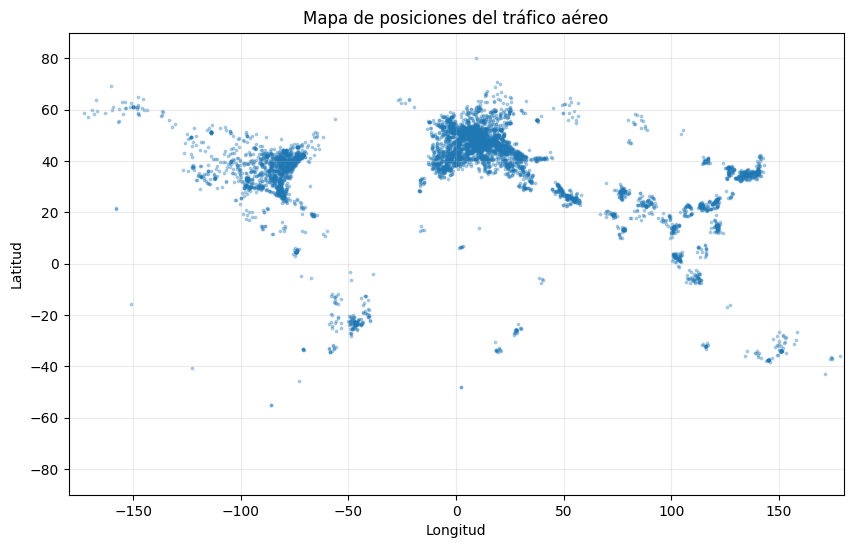

🗺️ Mapa scatter de posiciones generado.


In [ ]:
# --- Scatter geográfico de posiciones ---
# Se grafican las coordenadas válidas del snapshot dinámico para visualizar
# la distribución global del tráfico aéreo. 
#
# Se ajustan el tamaño de los puntos y la transparencia para obtener una
# visualización más clara, especialmente cuando hay miles de aeronaves.
# También se fijan los límites geográficos del mapa (-180 a 180, -90 a 90)
# para mantener una representación consistente del espacio geográfico.

df_coords = df_states_gold_final.dropna(subset=["latitude", "longitude"])

plt.scatter(
    df_coords["longitude"],
    df_coords["latitude"],
    s=3,           # puntos más pequeños → mayor claridad visual
    alpha=0.3      # mayor transparencia → evita saturación
)

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.title("Mapa de posiciones del tráfico aéreo")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True, alpha=0.25)

plt.show()

print("🗺️ Mapa scatter de posiciones generado.")

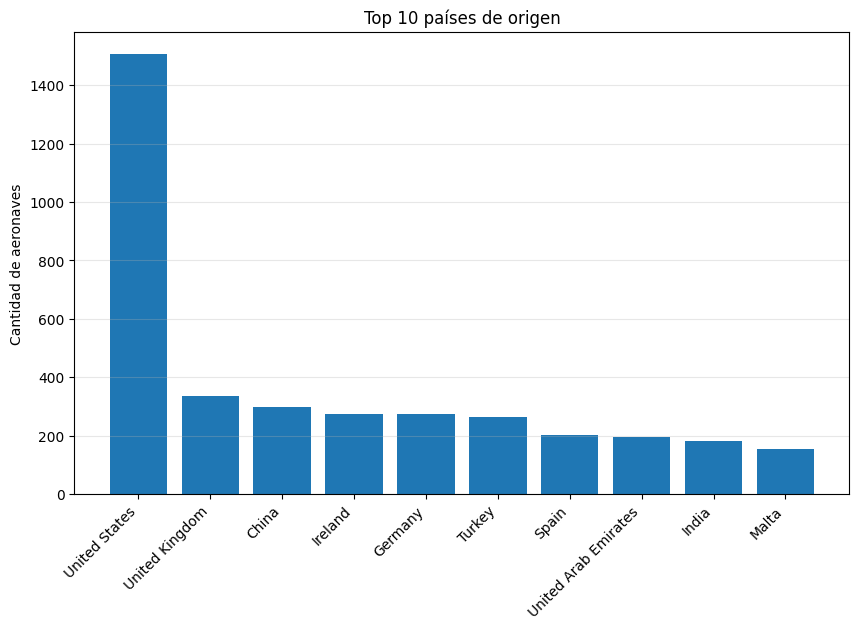

🌍 Gráfico de Top 10 países generado.


In [ ]:
# --- Gráfico de barras: Top 10 países de origen ---
# Permite observar rápidamente qué países contribuyen más al snapshot.

top_paises = (
    df_states_gold_final["origin_country"]
    .value_counts()
    .head(10)
)

plt.bar(top_paises.index, top_paises.values)
plt.title("Top 10 países de origen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cantidad de aeronaves")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

print("🌍 Gráfico de Top 10 países generado.")

In [74]:
# --- Distribución de modelos de aeronaves ---
# Se grafican los 10 modelos más frecuentes detectados en el snapshot Gold.

top_modelos = (
    df_states_gold_final["model"]
    .value_counts()
    .head(10)
)

plt.bar(top_modelos.index, top_modelos.values)
plt.title("Top 10 modelos de aeronaves")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cantidad")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

print("🛩️ Gráfico de modelos de aeronaves generado.")

KeyError: 'model'

### 4.6 Cierre del apartado Gold

En esta sección se consolidaron las **métricas descriptivas**, el **enriquecimiento con metadatos de aeronaves** y un conjunto de **visualizaciones básicas** que permiten validar el comportamiento general del tráfico aéreo capturado en el snapshot dinámico.

El propósito no es realizar un análisis aeronáutico exhaustivo, sino demostrar que los datos procesados a lo largo de la capa *Gold* son **coherentes, enriquecidos y listos para su utilización** en distintos entornos analíticos.

Las tareas principales realizadas incluyen:

- lectura del snapshot dinámico desde Silver  
- tipificación y normalización para análisis  
- cálculo de métricas operativas  
- integración con la tabla estática de aeronaves  
- preparación del dataset final consolidado  
- almacenamiento en Delta Lake (Gold)  
- exportación opcional a CSV/Parquet  
- generación de visualizaciones complementarias  

Con ello, la capa *Gold* completa el flujo **Bronze → Silver → Gold**, entregando un dataset final **curado, estructurado y enriquecido**, apto para análisis exploratorio, dashboards o procesamiento adicional en pipelines posteriores.

## 5. Conclusiones y roadmap del proyecto ETL_OpenSky

Este proyecto implementó un pipeline completo y profesional de Ingeniería de Datos sobre información aeronáutica pública, siguiendo la arquitectura **Bronze → Silver → Gold** y aplicando prácticas de limpieza, normalización, enriquecimiento y almacenamiento eficiente en **Delta Lake**.

El flujo local permitió construir un entorno reproducible y bien estructurado, mientras que la incorporación de la **orquestación con Prefect** habilita:

- ejecución automática y programada del pipeline  
- gestión centralizada de logs y monitoreo  
- control de dependencias entre tareas  
- capacidad de ingestas periódicas  
- mayor trazabilidad y estabilidad operativa  

Con ello, el pipeline se convierte en un sistema funcional y escalable, apto para procesar datos aeronáuticos de manera continua y confiable.

---

## 🔄 Roadmap futuro

Con la orquestación ya implementada, los siguientes pasos naturales del proyecto son:

### **1) Migración a Azure Cloud**
- almacenamiento en **Azure Data Lake / Blob Storage**  
- procesamiento distribuido con **Azure Databricks**  
- orquestación en la nube mediante **Prefect Cloud** o **Azure Data Factory**  
- integración con dashboards avanzados en Power BI  

### **2) Análisis histórico y dashboards**
- acumulación temporal de snapshots  
- construcción de series de tiempo sobre tráfico aéreo  
- visualizaciones geoespaciales enriquecidas y paneles ejecutivos  

---

## 🏁 Cierre

El proyecto demuestra la transformación completa de datos aeronáuticos heterogéneos en un dataset **moderno, limpio y analíticamente útil**. Gracias a la integración de Delta Lake y Prefect, el pipeline queda **automatizado, reproducible y preparado para su despliegue en la nube**, marcando una base sólida para ampliaciones futuras y análisis a mayor escala.